Packages loaded successfully.

Input files found.

Training: [1, 2, 3, 4, 5, 6, 7, 8]
Validation: [9, 10]
Post-treatment: [11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
Extracting features 2400/2400

Feature panel saved:
/Users/gaoyujuan/REAP Dropbox/Gao yujuan/Virginia Tech/CALS/datasets/test/ascm_validation/01_extracted_feature_panel.csv

Treatment 1/10
treatment_0001 | sentinel1

Training dimensions:
Treatment vector: (24,)
Donor matrix: (24, 5)

Selected lambda: 1.9952623149688788

Treatment 1/10
treatment_0001 | sentinel2

Training dimensions:
Treatment vector: (48,)
Donor matrix: (48, 5)

Selected lambda: 10000.0

Treatment 2/10
treatment_0002 | sentinel1

Training dimensions:
Treatment vector: (24,)
Donor matrix: (24, 5)

Selected lambda: 6.309573444801943

Treatment 2/10
treatment_0002 | sentinel2

Training dimensions:
Treatment vector: (40,)
Donor matrix: (40, 5)

Selected lambda: 7.943282347242821

Treatment 3/10
treatment_0003 | sentinel1

Training dimensions:
Treatment vector: (2

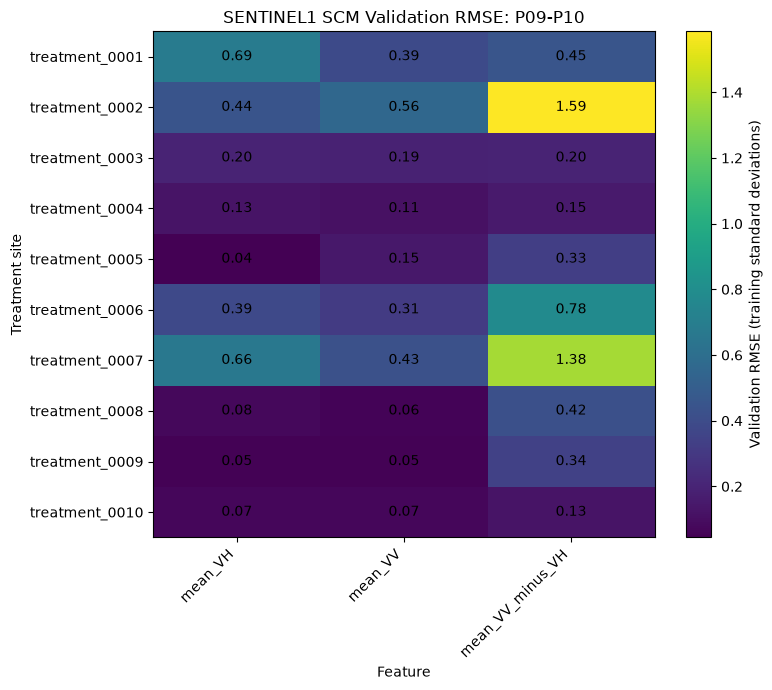

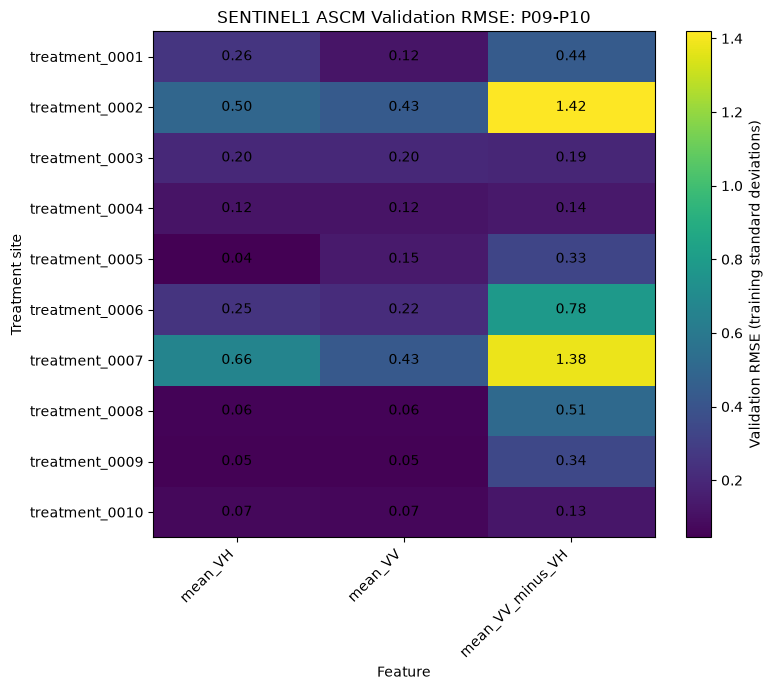

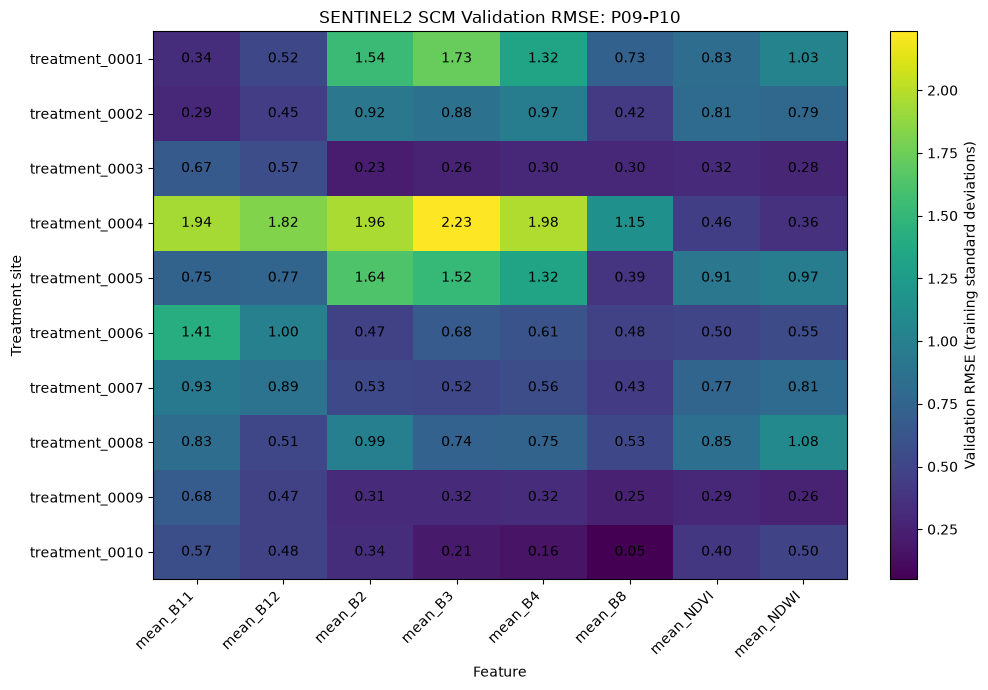

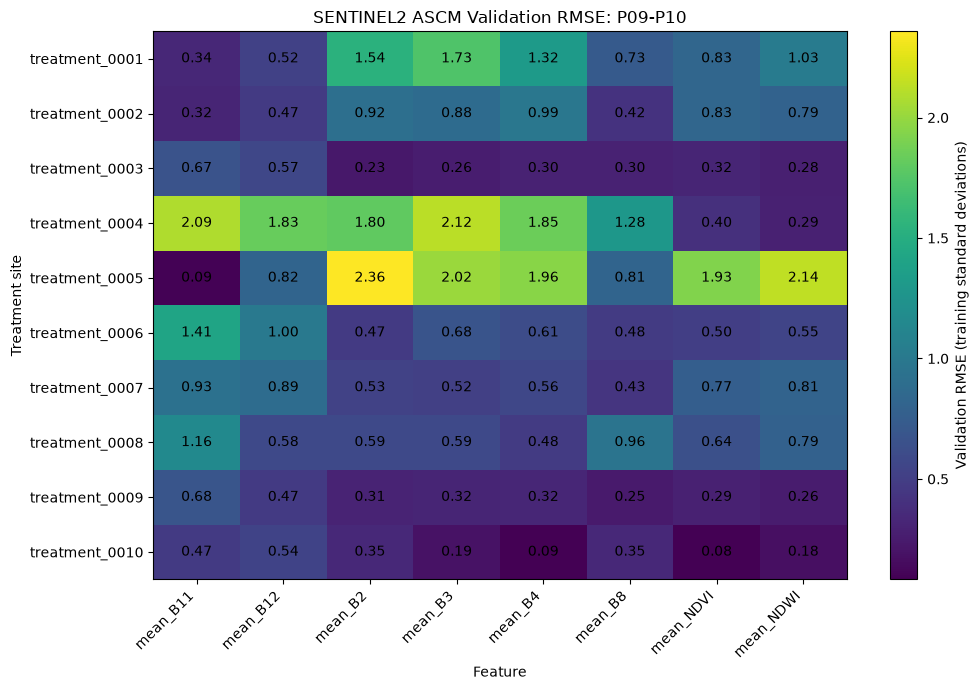

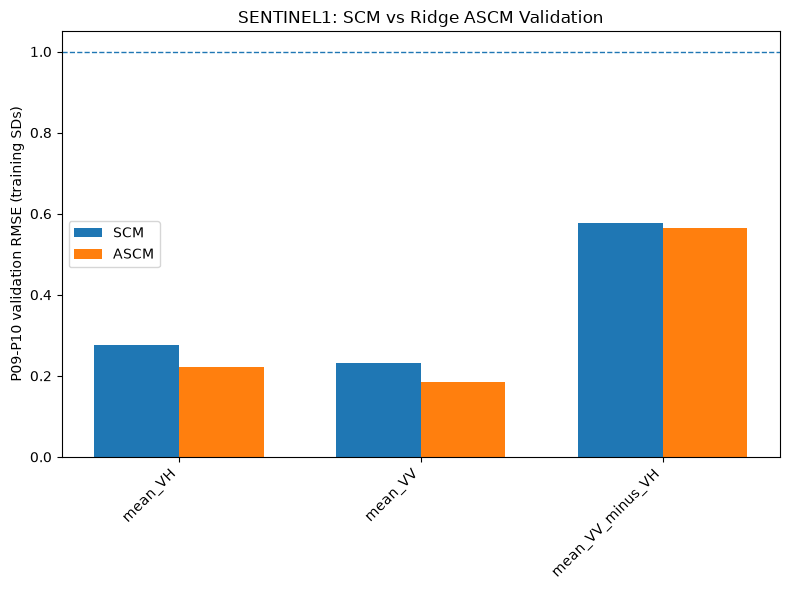

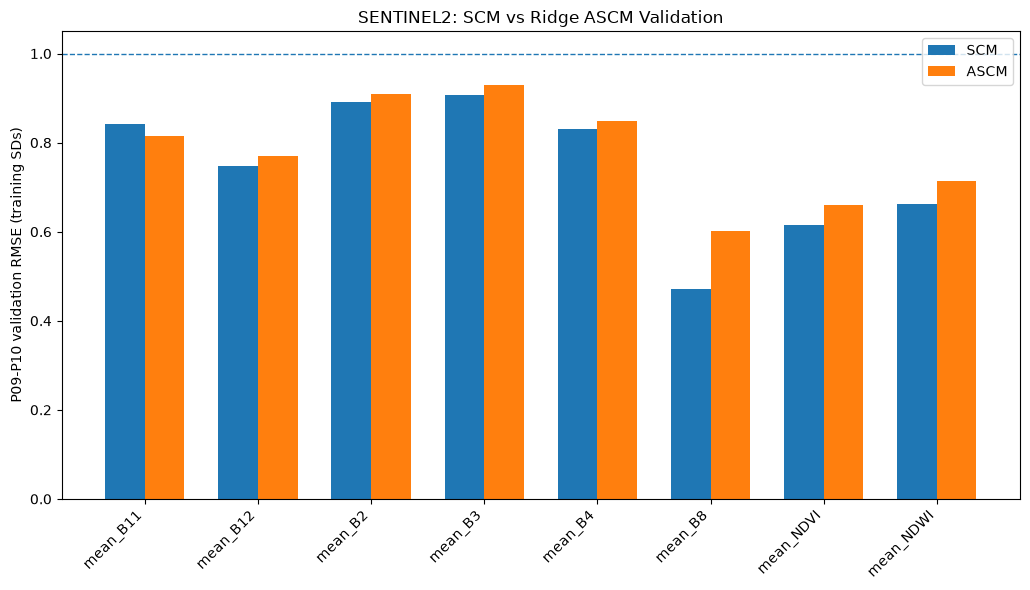


SCM vs RIDGE ASCM — HELD-OUT P09-P10 VALIDATION
treatment_site    sensor  scm_validation_rmse  ascm_validation_rmse  ascm_rmse_improvement  ascm_improves_validation
treatment_0010 sentinel1             0.093178              0.093241          -6.249074e-05                     False
treatment_0004 sentinel1             0.132290              0.125225           7.064970e-03                      True
treatment_0003 sentinel1             0.194835              0.198573          -3.738676e-03                     False
treatment_0009 sentinel1             0.202477              0.202477           1.773315e-11                      True
treatment_0005 sentinel1             0.209601              0.209606          -5.080851e-06                     False
treatment_0008 sentinel1             0.250729              0.299627          -4.889787e-02                     False
treatment_0001 sentinel1             0.525289              0.302061           2.232275e-01                      True
treatment_0006 

In [1]:
# =============================================================================
# 15_test_augmented_synthetic_control.ipynb
#
# PURPOSE
# =============================================================================
#
# Implement Ridge Augmented Synthetic Control (Ridge ASCM)
# following:
#
# Ben-Michael, Feller, and Rothstein (2021)
# "The Augmented Synthetic Control Method"
#
#
# DATA
# =============================================================================
#
# Uses the 14-day / biweekly dataset created by Notebook 12.
#
# Spatial sample:
#
#     10 treatment sites
#     5 counterfactual sites per treatment
#     50 counterfactual sites
#
#
# TEMPORAL DESIGN
# =============================================================================
#
# BEFORE HURRICANE:
#
#     P01-P08 = TRAINING
#
#     P09-P10 = HELD-OUT VALIDATION
#
#
# AFTER HURRICANE:
#
#     P11-P20 = EFFECT ESTIMATION
#
#
# IMPORTANT
# =============================================================================
#
# P09-P10 are NEVER used:
#
#     - to estimate SCM weights
#     - to choose Ridge ASCM lambda
#
# Lambda is selected using leave-one-training-period-out
# cross-validation using P01-P08 only.
#
#
# FEATURE DESIGN
# =============================================================================
#
# Sentinel-1:
#
#     mean_VV
#     mean_VH
#     mean_VV_minus_VH
#
#
# Sentinel-2:
#
#     mean_B2
#     mean_B3
#     mean_B4
#     mean_B8
#     mean_B11
#     mean_B12
#     mean_NDVI
#     mean_NDWI
#
#
# WEIGHT DESIGN
# =============================================================================
#
# One set of weights is estimated for:
#
#     treatment × sensor
#
# using all training-period features jointly.
#
#
# SCM:
#
#     min ||X_T - X_C w||^2
#
# subject to:
#
#     w_j >= 0
#     sum(w_j) = 1
#
#
# Ridge ASCM:
#
# Following Equation (18) of Ben-Michael et al. (2021):
#
#     min_w
#
#       (1 / (2 lambda)) ||X_T - X_C w||^2
#
#       +
#
#       (1 / 2) ||w - w_SCM||^2
#
# subject to:
#
#       sum(w_j) = 1
#
#
# ASCM allows negative weights.
#
# Lambda controls extrapolation:
#
#     large lambda
#         -> ASCM close to SCM
#
#     small lambda
#         -> more improvement in fit
#         -> more extrapolation
#
#
# OUTPUT
# =============================================================================
#
# test/
# └── ascm_validation/
#
#     ├── 01_extracted_feature_panel.csv
#     ├── 02_scm_weights.csv
#     ├── 03_ascm_weights.csv
#     ├── 04_lambda_selection.csv
#     ├── 05_validation_predictions.csv
#     ├── 06_validation_summary.csv
#     ├── 07_feature_validation_rmse.csv
#     ├── 08_post_hurricane_effects.csv
#     ├── 09_weight_diagnostics.csv
#     ├── 10_scm_vs_ascm_summary.csv
#     ├── ascm_results.xlsx
#     └── figures/
#
# =============================================================================


# =============================================================================
# 1. Packages
# =============================================================================

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import rasterio

from scipy.optimize import minimize

import matplotlib.pyplot as plt


warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
)


print(
    "Packages loaded successfully."
)


# =============================================================================
# 2. Paths
# =============================================================================

BASE_DIR = Path(
    "/Users/gaoyujuan/REAP Dropbox/Gao yujuan/"
    "Virginia Tech/CALS/datasets"
)


FINALS_DIR = (
    BASE_DIR /
    "finals"
)


BIWEEKLY_DIR = (
    FINALS_DIR /
    "biweekly_datasets"
)


BIWEEKLY_QUALITY_FILE = (
    BIWEEKLY_DIR /
    "biweekly_image_quality.csv"
)


SELECTED_SAMPLE_FILE = (
    FINALS_DIR /
    "daily_datasets" /
    "selected_site_sample.csv"
)

TEST_DIR = (
    BASE_DIR /
    "test"
)

OUTPUT_DIR = (
    TEST_DIR /
    "ascm_validation"
)


FIGURE_DIR = (
    OUTPUT_DIR /
    "figures"
)



OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


FEATURE_PANEL_FILE = (
    OUTPUT_DIR /
    "01_extracted_feature_panel.csv"
)


SCM_WEIGHT_FILE = (
    OUTPUT_DIR /
    "02_scm_weights.csv"
)


ASCM_WEIGHT_FILE = (
    OUTPUT_DIR /
    "03_ascm_weights.csv"
)


LAMBDA_FILE = (
    OUTPUT_DIR /
    "04_lambda_selection.csv"
)


VALIDATION_FILE = (
    OUTPUT_DIR /
    "05_validation_predictions.csv"
)


VALIDATION_SUMMARY_FILE = (
    OUTPUT_DIR /
    "06_validation_summary.csv"
)


FEATURE_RMSE_FILE = (
    OUTPUT_DIR /
    "07_feature_validation_rmse.csv"
)


EFFECT_FILE = (
    OUTPUT_DIR /
    "08_post_hurricane_effects.csv"
)


WEIGHT_DIAGNOSTIC_FILE = (
    OUTPUT_DIR /
    "09_weight_diagnostics.csv"
)


METHOD_COMPARISON_FILE = (
    OUTPUT_DIR /
    "10_scm_vs_ascm_summary.csv"
)


EXCEL_FILE = (
    OUTPUT_DIR /
    "ascm_results.xlsx"
)


# =============================================================================
# 3. Verify inputs
# =============================================================================

for file_path in [

    BIWEEKLY_QUALITY_FILE,

    SELECTED_SAMPLE_FILE,

]:

    if not file_path.exists():

        raise FileNotFoundError(
            f"Required file missing:\n{file_path}"
        )


print(
    "\nInput files found."
)


# =============================================================================
# 4. Feature definitions
# =============================================================================

SENSOR_FEATURES = {

    "sentinel1": [

        "mean_VV",

        "mean_VH",

        "mean_VV_minus_VH",

    ],


    "sentinel2": [

        "mean_B2",

        "mean_B3",

        "mean_B4",

        "mean_B8",

        "mean_B11",

        "mean_B12",

        "mean_NDVI",

        "mean_NDWI",

    ],

}


SENSOR_BANDS = {

    "sentinel1": [

        "VV",

        "VH",

        "VV_minus_VH",

    ],


    "sentinel2": [

        "B2",

        "B3",

        "B4",

        "B8",

        "B11",

        "B12",

        "NDVI",

        "NDWI",

    ],

}


# =============================================================================
# 5. Temporal design
# =============================================================================

TRAIN_PERIODS = list(
    range(
        1,
        9,
    )
)


VALIDATION_PERIODS = [

    9,

    10,

]


POST_PERIODS = list(
    range(
        11,
        21,
    )
)


print(
    "\nTraining:",
    TRAIN_PERIODS
)


print(
    "Validation:",
    VALIDATION_PERIODS
)


print(
    "Post-treatment:",
    POST_PERIODS
)


# =============================================================================
# 6. Convert original period to P01-P20
# =============================================================================

def convert_to_global_period(
    period,
    period_number,
):

    period_number = int(
        period_number
    )


    if str(
        period
    ).lower() == "before":

        return period_number


    if str(
        period
    ).lower() == "after":

        return (
            period_number
            +
            10
        )


    raise ValueError(
        f"Unknown period: {period}"
    )


# =============================================================================
# 7. Read spatial means from TIFF
# =============================================================================

def extract_band_means(
    file_path,
    band_names,
):

    if (
        pd.isna(
            file_path
        )
        or
        not Path(
            file_path
        ).exists()
    ):

        return {

            f"mean_{band}":
                np.nan

            for band
            in band_names

        }


    with rasterio.open(
        file_path
    ) as src:

        data = (
            src
            .read(
                masked=True
            )
            .astype(
                "float64"
            )
            .filled(
                np.nan
            )
        )


    output = {}


    for band_index, band_name in enumerate(
        band_names
    ):

        values = (
            data[
                band_index
            ]
        )


        output[
            f"mean_{band_name}"
        ] = (
            float(
                np.nanmean(
                    values
                )
            )
            if
            np.isfinite(
                values
            ).any()
            else
            np.nan
        )


    return output


# =============================================================================
# 8. Load sample
# =============================================================================

selected_sample = pd.read_csv(
    SELECTED_SAMPLE_FILE
)


selected_sample[
    "site_id"
] = (
    selected_sample[
        "site_id"
    ]
    .astype(str)
)


selected_sample[
    "group"
] = (
    selected_sample[
        "group"
    ]
    .astype(str)
    .str.lower()
)


selected_sample[
    "matched_treatment_site_id"
] = (
    selected_sample[
        "matched_treatment_site_id"
    ]
    .astype(str)
)


selected_sample[
    "control_rank"
] = pd.to_numeric(
    selected_sample[
        "control_rank"
    ],
    errors="coerce",
)


# =============================================================================
# 9. Load biweekly quality inventory
# =============================================================================

inventory = pd.read_csv(
    BIWEEKLY_QUALITY_FILE
)


inventory[
    "site_id"
] = (
    inventory[
        "site_id"
    ]
    .astype(str)
)


inventory[
    "sensor"
] = (
    inventory[
        "sensor"
    ]
    .astype(str)
    .str.lower()
)


inventory[
    "group"
] = (
    inventory[
        "group"
    ]
    .astype(str)
    .str.lower()
)


inventory[
    "global_period"
] = [

    convert_to_global_period(
        period,
        period_number,
    )

    for period, period_number
    in zip(
        inventory[
            "period"
        ],
        inventory[
            "period_number"
        ],
    )

]


inventory[
    "global_period_id"
] = (

    "P"
    +
    inventory[
        "global_period"
    ]
    .astype(int)
    .astype(str)
    .str.zfill(
        2
    )

)


# =============================================================================
# 10. Extract feature panel
# =============================================================================

feature_records = []


total_rows = len(
    inventory
)


for row_number, (_, row) in enumerate(
    inventory.iterrows(),
    start=1,
):

    sensor = str(
        row[
            "sensor"
        ]
    )


    if sensor not in SENSOR_BANDS:

        continue


    print(
        f"\rExtracting features "
        f"{row_number}/{total_rows}",
        end="",
    )


    feature_values = (
        extract_band_means(

            file_path=
                row.get(
                    "output_file"
                ),

            band_names=
                SENSOR_BANDS[
                    sensor
                ],

        )
    )


    record = {

        "site_id":
            str(
                row[
                    "site_id"
                ]
            ),

        "group":
            str(
                row[
                    "group"
                ]
            ),

        "sensor":
            sensor,

        "period":
            row[
                "period"
            ],

        "period_number":
            int(
                row[
                    "period_number"
                ]
            ),

        "global_period":
            int(
                row[
                    "global_period"
                ]
            ),

        "global_period_id":
            row[
                "global_period_id"
            ],

        "output_file":
            row.get(
                "output_file"
            ),

    }


    record.update(
        feature_values
    )


    feature_records.append(
        record
    )


print()


feature_panel = pd.DataFrame(
    feature_records
)


# Attach matching metadata.

metadata = (
    selected_sample[
        [
            "site_id",
            "group",
            "matched_treatment_site_id",
            "control_rank",
        ]
    ]
    .drop_duplicates()
)


feature_panel = (
    feature_panel
    .merge(
        metadata,
        on=[
            "site_id",
            "group",
        ],
        how="left",
    )
)


feature_panel.to_csv(
    FEATURE_PANEL_FILE,
    index=False,
)


print(
    "\nFeature panel saved:"
)


print(
    FEATURE_PANEL_FILE
)


# =============================================================================
# 11. Helper: obtain donor IDs
# =============================================================================

def get_donor_ids(
    treatment_site,
):

    donors = (
        selected_sample
        .loc[
            (
                selected_sample[
                    "group"
                ]
                ==
                "counterfactual"
            )
            &
            (
                selected_sample[
                    "matched_treatment_site_id"
                ]
                ==
                str(
                    treatment_site
                )
            )
        ]
        .sort_values(
            "control_rank"
        )
    )


    return (
        donors[
            "site_id"
        ]
        .astype(str)
        .tolist()
    )


# =============================================================================
# 12. Build treatment × donor matrices
# =============================================================================

def get_sensor_panel(
    treatment_site,
    sensor,
):

    features = (
        SENSOR_FEATURES[
            sensor
        ]
    )


    donor_ids = (
        get_donor_ids(
            treatment_site
        )
    )


    treatment = (
        feature_panel
        .loc[
            (
                feature_panel[
                    "site_id"
                ]
                ==
                str(
                    treatment_site
                )
            )
            &
            (
                feature_panel[
                    "sensor"
                ]
                ==
                sensor
            )
        ]
        .sort_values(
            "global_period"
        )
        .copy()
    )


    donors = (
        feature_panel
        .loc[
            (
                feature_panel[
                    "site_id"
                ]
                .isin(
                    donor_ids
                )
            )
            &
            (
                feature_panel[
                    "sensor"
                ]
                ==
                sensor
            )
        ]
        .copy()
    )


    return (

        treatment,

        donors,

        donor_ids,

        features,

    )


# =============================================================================
# 13. Feature standardization
#
# Statistics are estimated from P01-P08 ONLY.
#
# One mean / SD per feature.
#
# We use donor training observations to define the scale.
# =============================================================================

def calculate_training_scaler(
    donors,
    features,
):

    train = (
        donors
        .loc[
            donors[
                "global_period"
            ]
            .isin(
                TRAIN_PERIODS
            )
        ]
        .copy()
    )


    means = {}


    stds = {}


    for feature in features:

        values = pd.to_numeric(
            train[
                feature
            ],
            errors="coerce",
        )


        means[
            feature
        ] = float(
            values.mean()
        )


        sd = float(
            values.std(
                ddof=0
            )
        )


        if (
            not np.isfinite(
                sd
            )
            or
            sd < 1e-8
        ):

            sd = 1.0


        stds[
            feature
        ] = (
            sd
        )


    return (
        means,
        stds,
    )


def standardize_frame(
    dataframe,
    features,
    means,
    stds,
):

    dataframe = (
        dataframe.copy()
    )


    for feature in features:

        dataframe[
            feature
        ] = (

            pd.to_numeric(
                dataframe[
                    feature
                ],
                errors="coerce",
            )
            -
            means[
                feature
            ]

        ) / stds[
            feature
        ]


    return dataframe


# =============================================================================
# 14. Build wide X matrix
#
# Rows of X = period × feature
# Columns = donor sites
#
# Example Sentinel-2:
#
# P01 B2
# P01 B3
# ...
# P01 NDWI
# P02 B2
# ...
#
# =============================================================================

def create_design_matrices(
    treatment,
    donors,
    donor_ids,
    features,
    periods,
):

    treated_values = []


    donor_values = []


    labels = []


    for period_number in periods:

        treated_period = (
            treatment
            .loc[
                treatment[
                    "global_period"
                ]
                ==
                period_number
            ]
        )


        if treated_period.empty:

            raise ValueError(
                f"Treatment missing P{period_number:02d}"
            )


        for feature in features:

            treated_value = (
                treated_period[
                    feature
                ]
                .iloc[
                    0
                ]
            )


            current_donors = []


            for donor_id in donor_ids:

                donor_period = (
                    donors
                    .loc[
                        (
                            donors[
                                "site_id"
                            ]
                            ==
                            donor_id
                        )
                        &
                        (
                            donors[
                                "global_period"
                            ]
                            ==
                            period_number
                        )
                    ]
                )


                if donor_period.empty:

                    donor_value = (
                        np.nan
                    )


                else:

                    donor_value = (
                        donor_period[
                            feature
                        ]
                        .iloc[
                            0
                        ]
                    )


                current_donors.append(
                    donor_value
                )


            treated_values.append(
                treated_value
            )


            donor_values.append(
                current_donors
            )


            labels.append(
                (
                    period_number,
                    feature,
                )
            )


    x_treated = np.asarray(
        treated_values,
        dtype=float,
    )


    X_donors = np.asarray(
        donor_values,
        dtype=float,
    )


    return (
        x_treated,
        X_donors,
        labels,
    )


# =============================================================================
# 15. Missing-data handling
#
# We retain only period × feature rows where:
#
#     treated value is finite
#     AND
#     all 5 donors are finite
#
# =============================================================================

def remove_missing_rows(
    x_treated,
    X_donors,
    labels,
):

    valid = (

        np.isfinite(
            x_treated
        )
        &
        np.isfinite(
            X_donors
        )
        .all(
            axis=1
        )

    )


    return (

        x_treated[
            valid
        ],

        X_donors[
            valid,
            :
        ],

        [

            label

            for label, keep
            in zip(
                labels,
                valid,
            )

            if keep

        ],

    )


# =============================================================================
# 16. Ordinary SCM
# =============================================================================

def fit_scm(
    x_treated,
    X_donors,
):

    number_of_donors = (
        X_donors.shape[
            1
        ]
    )


    initial_weights = np.repeat(
        1.0
        /
        number_of_donors,
        number_of_donors,
    )


    def objective(
        weights,
    ):

        residual = (

            x_treated
            -
            X_donors
            @
            weights

        )


        return float(
            np.mean(
                residual ** 2
            )
        )


    constraints = [

        {

            "type":
                "eq",

            "fun":
                lambda weights:
                    np.sum(
                        weights
                    )
                    -
                    1.0,

        }

    ]


    bounds = [

        (
            0.0,
            1.0,
        )

        for _
        in range(
            number_of_donors
        )

    ]


    result = minimize(

        objective,

        initial_weights,

        method=
            "SLSQP",

        bounds=
            bounds,

        constraints=
            constraints,

        options={

            "maxiter":
                5000,

            "ftol":
                1e-12,

        },

    )


    if not result.success:

        raise RuntimeError(
            "SCM optimization failed: "
            +
            result.message
        )


    return result.x


# =============================================================================
# 17. Ridge ASCM
#
# Direct implementation of Equation (18):
#
# min
#
#   1/(2 lambda) ||x - Xw||²
#
#   + 1/2 ||w - w_SCM||²
#
# subject to:
#
#   sum(w) = 1
#
#
# Negative weights ARE allowed.
# =============================================================================

def fit_ridge_ascm(
    x_treated,
    X_donors,
    scm_weights,
    lambda_value,
):

    number_of_donors = (
        X_donors.shape[
            1
        ]
    )


    A = (
        X_donors
    )


    H = (

        np.eye(
            number_of_donors
        )

        +

        (
            A.T
            @
            A
        )
        /
        lambda_value

    )


    b = (

        scm_weights

        +

        (
            A.T
            @
            x_treated
        )
        /
        lambda_value

    )


    ones = np.ones(
        (
            number_of_donors,
            1,
        )
    )


    KKT = np.block(

        [

            [
                H,
                ones,
            ],

            [
                ones.T,
                np.zeros(
                    (
                        1,
                        1,
                    )
                ),
            ],

        ]

    )


    rhs = np.concatenate(

        [

            b,

            np.asarray(
                [
                    1.0
                ]
            ),

        ]

    )


    solution = np.linalg.solve(
        KKT,
        rhs,
    )


    weights = (
        solution[
            :
            number_of_donors
        ]
    )


    return weights


# =============================================================================
# 18. Lambda grid
# =============================================================================

LAMBDA_GRID = np.logspace(
    -4,
    4,
    81,
)


# =============================================================================
# 19. Leave-one-training-period-out CV
#
# Paper:
#
# Equation (27)
#
# CV(lambda) =
#
#     sum_t (Y_t - Yhat_t^(-t))²
#
#
# Here:
#
# one entire biweekly period is held out,
# meaning ALL features for that period are withheld together.
# =============================================================================

def cross_validate_lambda(
    treatment,
    donors,
    donor_ids,
    features,
):

    cv_records = []


    for lambda_value in LAMBDA_GRID:

        squared_errors = []


        number_predictions = 0


        for holdout_period in TRAIN_PERIODS:

            fit_periods = [

                period

                for period
                in TRAIN_PERIODS

                if period
                !=
                holdout_period

            ]


            (
                x_fit,
                X_fit,
                labels_fit,
            ) = (
                create_design_matrices(

                    treatment=
                        treatment,

                    donors=
                        donors,

                    donor_ids=
                        donor_ids,

                    features=
                        features,

                    periods=
                        fit_periods,

                )
            )


            (
                x_fit,
                X_fit,
                labels_fit,
            ) = (
                remove_missing_rows(
                    x_fit,
                    X_fit,
                    labels_fit,
                )
            )


            if len(
                x_fit
            ) == 0:

                continue


            scm_weights = (
                fit_scm(
                    x_fit,
                    X_fit,
                )
            )


            ascm_weights = (
                fit_ridge_ascm(

                    x_treated=
                        x_fit,

                    X_donors=
                        X_fit,

                    scm_weights=
                        scm_weights,

                    lambda_value=
                        lambda_value,

                )
            )


            (
                x_test,
                X_test,
                labels_test,
            ) = (
                create_design_matrices(

                    treatment=
                        treatment,

                    donors=
                        donors,

                    donor_ids=
                        donor_ids,

                    features=
                        features,

                    periods=[
                        holdout_period
                    ],

                )
            )


            (
                x_test,
                X_test,
                labels_test,
            ) = (
                remove_missing_rows(
                    x_test,
                    X_test,
                    labels_test,
                )
            )


            if len(
                x_test
            ) == 0:

                continue


            prediction = (
                X_test
                @
                ascm_weights
            )


            errors = (
                x_test
                -
                prediction
            )


            squared_errors.extend(
                (
                    errors ** 2
                ).tolist()
            )


            number_predictions += len(
                errors
            )


        cv_mse = (
            float(
                np.mean(
                    squared_errors
                )
            )
            if squared_errors
            else np.nan
        )


        cv_records.append(
            {

                "lambda":
                    lambda_value,

                "cv_mse":
                    cv_mse,

                "cv_rmse":
                    np.sqrt(
                        cv_mse
                    )
                    if np.isfinite(
                        cv_mse
                    )
                    else np.nan,

                "number_of_predictions":
                    number_predictions,

            }
        )


    cv_table = pd.DataFrame(
        cv_records
    )


    valid = (
        cv_table
        .dropna(
            subset=[
                "cv_mse"
            ]
        )
    )


    if valid.empty:

        raise RuntimeError(
            "Lambda cross-validation produced no valid result."
        )


    best_row = (
        valid
        .sort_values(
            "cv_mse"
        )
        .iloc[
            0
        ]
    )


    best_lambda = float(
        best_row[
            "lambda"
        ]
    )


    return (
        best_lambda,
        cv_table,
    )


# =============================================================================
# 20. Prediction helper
# =============================================================================

def predict_period(
    treatment,
    donors,
    donor_ids,
    features,
    period_number,
    weights,
):

    (
        x,
        X,
        labels,
    ) = (
        create_design_matrices(

            treatment=
                treatment,

            donors=
                donors,

            donor_ids=
                donor_ids,

            features=
                features,

            periods=[
                period_number
            ],

        )
    )


    records = []


    for row_number, (
        period,
        feature,
    ) in enumerate(
        labels
    ):

        actual = (
            x[
                row_number
            ]
        )


        donor_values = (
            X[
                row_number,
                :
            ]
        )


        if (
            not np.isfinite(
                actual
            )
            or
            not np.isfinite(
                donor_values
            ).all()
        ):

            predicted = (
                np.nan
            )


        else:

            predicted = float(
                donor_values
                @
                weights
            )


        records.append(
            {

                "global_period":
                    period,

                "global_period_id":
                    (
                        f"P{period:02d}"
                    ),

                "feature":
                    feature,

                "actual":
                    actual,

                "synthetic":
                    predicted,

                "gap":
                    (
                        actual
                        -
                        predicted
                    )
                    if
                    np.isfinite(
                        actual
                    )
                    and
                    np.isfinite(
                        predicted
                    )
                    else np.nan,

            }
        )


    return records


# =============================================================================
# 21. Run SCM + ASCM
# =============================================================================

treatment_sites = (

    selected_sample
    .loc[
        selected_sample[
            "group"
        ]
        ==
        "treatment",
        "site_id",
    ]
    .drop_duplicates()
    .astype(str)
    .tolist()

)


scm_weight_records = []


ascm_weight_records = []


lambda_records = []


validation_records = []


effect_records = []


diagnostic_records = []


trajectory_records = []


for treatment_number, treatment_site in enumerate(
    treatment_sites,
    start=1,
):

    for sensor in [

        "sentinel1",

        "sentinel2",

    ]:

        print(
            "\n"
            + "=" * 100
        )


        print(
            f"Treatment "
            f"{treatment_number}/"
            f"{len(treatment_sites)}"
        )


        print(
            treatment_site,
            "|",
            sensor
        )


        print(
            "=" * 100
        )


        (
            treatment,
            donors,
            donor_ids,
            features,
        ) = (
            get_sensor_panel(
                treatment_site=
                    treatment_site,
                sensor=
                    sensor,
            )
        )


        if len(
            donor_ids
        ) == 0:

            print(
                "No matched donors."
            )

            continue


        # =====================================================================
        # Standardize using P01-P08 donor data
        # =====================================================================

        means, stds = (
            calculate_training_scaler(
                donors,
                features,
            )
        )


        treatment_z = (
            standardize_frame(
                treatment,
                features,
                means,
                stds,
            )
        )


        donors_z = (
            standardize_frame(
                donors,
                features,
                means,
                stds,
            )
        )


        # =====================================================================
        # TRAINING MATRIX P01-P08
        # =====================================================================

        (
            x_train,
            X_train,
            train_labels,
        ) = (
            create_design_matrices(

                treatment=
                    treatment_z,

                donors=
                    donors_z,

                donor_ids=
                    donor_ids,

                features=
                    features,

                periods=
                    TRAIN_PERIODS,

            )
        )


        (
            x_train,
            X_train,
            train_labels,
        ) = (
            remove_missing_rows(
                x_train,
                X_train,
                train_labels,
            )
        )


        print(
            "\nTraining dimensions:"
        )


        print(
            "Treatment vector:",
            x_train.shape
        )


        print(
            "Donor matrix:",
            X_train.shape
        )


        # =====================================================================
        # SCM
        # =====================================================================

        scm_weights = (
            fit_scm(
                x_train,
                X_train,
            )
        )


        scm_training_prediction = (
            X_train
            @
            scm_weights
        )


        scm_training_rmse = float(
            np.sqrt(
                np.mean(
                    (
                        x_train
                        -
                        scm_training_prediction
                    )
                    **
                    2
                )
            )
        )


        # =====================================================================
        # Select ASCM lambda using P01-P08 only
        # =====================================================================

        best_lambda, cv_table = (
            cross_validate_lambda(

                treatment=
                    treatment_z,

                donors=
                    donors_z,

                donor_ids=
                    donor_ids,

                features=
                    features,

            )
        )


        print(
            "\nSelected lambda:",
            best_lambda
        )


        cv_table[
            "treatment_site"
        ] = (
            treatment_site
        )


        cv_table[
            "sensor"
        ] = (
            sensor
        )


        lambda_records.extend(
            cv_table.to_dict(
                "records"
            )
        )


        # =====================================================================
        # Final ASCM weights
        # =====================================================================

        ascm_weights = (
            fit_ridge_ascm(

                x_treated=
                    x_train,

                X_donors=
                    X_train,

                scm_weights=
                    scm_weights,

                lambda_value=
                    best_lambda,

            )
        )


        ascm_training_prediction = (
            X_train
            @
            ascm_weights
        )


        ascm_training_rmse = float(
            np.sqrt(
                np.mean(
                    (
                        x_train
                        -
                        ascm_training_prediction
                    )
                    **
                    2
                )
            )
        )


        # =====================================================================
        # Save weights
        # =====================================================================

        for donor_number, donor_id in enumerate(
            donor_ids
        ):

            scm_weight_records.append(
                {

                    "treatment_site":
                        treatment_site,

                    "sensor":
                        sensor,

                    "donor_site":
                        donor_id,

                    "weight":
                        scm_weights[
                            donor_number
                        ],

                }
            )


            ascm_weight_records.append(
                {

                    "treatment_site":
                        treatment_site,

                    "sensor":
                        sensor,

                    "donor_site":
                        donor_id,

                    "lambda":
                        best_lambda,

                    "scm_weight":
                        scm_weights[
                            donor_number
                        ],

                    "ascm_weight":
                        ascm_weights[
                            donor_number
                        ],

                    "weight_adjustment":
                        (
                            ascm_weights[
                                donor_number
                            ]
                            -
                            scm_weights[
                                donor_number
                            ]
                        ),

                }
            )


        # =====================================================================
        # Extrapolation diagnostics
        #
        # The paper recommends examining how far ASCM moves
        # away from SCM weights.
        # =====================================================================

        weight_distance = float(
            np.sqrt(
                np.mean(
                    (
                        ascm_weights
                        -
                        scm_weights
                    )
                    **
                    2
                )
            )
        )


        negative_weight_count = int(
            (
                ascm_weights
                <
                0
            )
            .sum()
        )


        total_negative_weight = float(

            np.abs(
                ascm_weights[
                    ascm_weights
                    <
                    0
                ]
            )
            .sum()

        )


        diagnostic_records.append(
            {

                "treatment_site":
                    treatment_site,

                "sensor":
                    sensor,

                "lambda":
                    best_lambda,

                "scm_training_rmse":
                    scm_training_rmse,

                "ascm_training_rmse":
                    ascm_training_rmse,

                "training_rmse_improvement":
                    (
                        scm_training_rmse
                        -
                        ascm_training_rmse
                    ),

                "weight_rmse_distance_from_scm":
                    weight_distance,

                "negative_weight_count":
                    negative_weight_count,

                "total_absolute_negative_weight":
                    total_negative_weight,

                "minimum_ascm_weight":
                    float(
                        ascm_weights.min()
                    ),

                "maximum_ascm_weight":
                    float(
                        ascm_weights.max()
                    ),

                "sum_ascm_weights":
                    float(
                        ascm_weights.sum()
                    ),

            }
        )


        # =====================================================================
        # Generate predictions P01-P20
        # =====================================================================

        for period_number in range(
            1,
            21,
        ):

            # SCM
            scm_predictions = (
                predict_period(

                    treatment=
                        treatment_z,

                    donors=
                        donors_z,

                    donor_ids=
                        donor_ids,

                    features=
                        features,

                    period_number=
                        period_number,

                    weights=
                        scm_weights,

                )
            )


            # ASCM
            ascm_predictions = (
                predict_period(

                    treatment=
                        treatment_z,

                    donors=
                        donors_z,

                    donor_ids=
                        donor_ids,

                    features=
                        features,

                    period_number=
                        period_number,

                    weights=
                        ascm_weights,

                )
            )


            for scm_record, ascm_record in zip(
                scm_predictions,
                ascm_predictions,
            ):

                base = {

                    "treatment_site":
                        treatment_site,

                    "sensor":
                        sensor,

                    "global_period":
                        period_number,

                    "global_period_id":
                        f"P{period_number:02d}",

                    "feature":
                        scm_record[
                            "feature"
                        ],

                    "actual_standardized":
                        scm_record[
                            "actual"
                        ],

                    "scm_synthetic_standardized":
                        scm_record[
                            "synthetic"
                        ],

                    "scm_gap_standardized":
                        scm_record[
                            "gap"
                        ],

                    "ascm_synthetic_standardized":
                        ascm_record[
                            "synthetic"
                        ],

                    "ascm_gap_standardized":
                        ascm_record[
                            "gap"
                        ],

                }


                trajectory_records.append(
                    base
                )


                # -------------------------------------------------------------
                # P09-P10 validation
                # -------------------------------------------------------------

                if (
                    period_number
                    in
                    VALIDATION_PERIODS
                ):

                    validation_records.append(
                        base.copy()
                    )


                # -------------------------------------------------------------
                # P11-P20 hurricane effect
                # -------------------------------------------------------------

                if (
                    period_number
                    in
                    POST_PERIODS
                ):

                    effect_records.append(
                        base.copy()
                    )


# =============================================================================
# 22. Convert to DataFrames
# =============================================================================

scm_weights_df = pd.DataFrame(
    scm_weight_records
)


ascm_weights_df = pd.DataFrame(
    ascm_weight_records
)


lambda_df = pd.DataFrame(
    lambda_records
)


validation = pd.DataFrame(
    validation_records
)


effects = pd.DataFrame(
    effect_records
)


diagnostics = pd.DataFrame(
    diagnostic_records
)


trajectories = pd.DataFrame(
    trajectory_records
)


# =============================================================================
# 23. Validation errors
# =============================================================================

validation[
    "scm_squared_error"
] = (
    validation[
        "scm_gap_standardized"
    ]
    **
    2
)


validation[
    "ascm_squared_error"
] = (
    validation[
        "ascm_gap_standardized"
    ]
    **
    2
)


# =============================================================================
# 24. Overall P09-P10 validation by treatment × sensor
# =============================================================================

validation_summary = (
    validation
    .groupby(
        [
            "treatment_site",
            "sensor",
        ],
        as_index=False,
    )
    .agg(

        scm_validation_rmse=(
            "scm_squared_error",
            lambda x:
                float(
                    np.sqrt(
                        np.nanmean(
                            x
                        )
                    )
                ),
        ),

        ascm_validation_rmse=(
            "ascm_squared_error",
            lambda x:
                float(
                    np.sqrt(
                        np.nanmean(
                            x
                        )
                    )
                ),
        ),

    )
)


validation_summary[
    "ascm_rmse_improvement"
] = (

    validation_summary[
        "scm_validation_rmse"
    ]

    -

    validation_summary[
        "ascm_validation_rmse"
    ]

)


validation_summary[
    "ascm_improves_validation"
] = (

    validation_summary[
        "ascm_validation_rmse"
    ]

    <

    validation_summary[
        "scm_validation_rmse"
    ]

)


# =============================================================================
# 25. Feature-specific validation RMSE
# =============================================================================

feature_validation_rmse = (
    validation
    .groupby(
        [
            "treatment_site",
            "sensor",
            "feature",
        ],
        as_index=False,
    )
    .agg(

        scm_rmse=(
            "scm_squared_error",
            lambda x:
                float(
                    np.sqrt(
                        np.nanmean(
                            x
                        )
                    )
                ),
        ),

        ascm_rmse=(
            "ascm_squared_error",
            lambda x:
                float(
                    np.sqrt(
                        np.nanmean(
                            x
                        )
                    )
                ),
        ),

    )
)


feature_validation_rmse[
    "rmse_improvement"
] = (

    feature_validation_rmse[
        "scm_rmse"
    ]

    -

    feature_validation_rmse[
        "ascm_rmse"
    ]

)


# =============================================================================
# 26. SCM vs ASCM summary
# =============================================================================

method_comparison = (
    feature_validation_rmse
    .groupby(
        [
            "sensor",
            "feature",
        ],
        as_index=False,
    )
    .agg(

        mean_scm_validation_rmse=(
            "scm_rmse",
            "mean",
        ),

        mean_ascm_validation_rmse=(
            "ascm_rmse",
            "mean",
        ),

        median_scm_validation_rmse=(
            "scm_rmse",
            "median",
        ),

        median_ascm_validation_rmse=(
            "ascm_rmse",
            "median",
        ),

        treatments_ascm_better=(
            "rmse_improvement",
            lambda x:
                int(
                    (
                        x > 0
                    )
                    .sum()
                ),
        ),

        number_of_treatments=(
            "treatment_site",
            "nunique",
        ),

    )
)


method_comparison[
    "mean_rmse_improvement"
] = (

    method_comparison[
        "mean_scm_validation_rmse"
    ]

    -

    method_comparison[
        "mean_ascm_validation_rmse"
    ]

)


# =============================================================================
# 27. Save outputs
# =============================================================================

scm_weights_df.to_csv(
    SCM_WEIGHT_FILE,
    index=False,
)


ascm_weights_df.to_csv(
    ASCM_WEIGHT_FILE,
    index=False,
)


lambda_df.to_csv(
    LAMBDA_FILE,
    index=False,
)


validation.to_csv(
    VALIDATION_FILE,
    index=False,
)


validation_summary.to_csv(
    VALIDATION_SUMMARY_FILE,
    index=False,
)


feature_validation_rmse.to_csv(
    FEATURE_RMSE_FILE,
    index=False,
)


effects.to_csv(
    EFFECT_FILE,
    index=False,
)


diagnostics.to_csv(
    WEIGHT_DIAGNOSTIC_FILE,
    index=False,
)


method_comparison.to_csv(
    METHOD_COMPARISON_FILE,
    index=False,
)


# =============================================================================
# 28. Excel
# =============================================================================

with pd.ExcelWriter(
    EXCEL_FILE,
    engine="openpyxl",
) as writer:

    validation_summary.to_excel(
        writer,
        sheet_name="validation_summary",
        index=False,
    )


    feature_validation_rmse.to_excel(
        writer,
        sheet_name="feature_validation",
        index=False,
    )


    method_comparison.to_excel(
        writer,
        sheet_name="SCM_vs_ASCM",
        index=False,
    )


    diagnostics.to_excel(
        writer,
        sheet_name="weight_diagnostics",
        index=False,
    )


    ascm_weights_df.to_excel(
        writer,
        sheet_name="ASCM_weights",
        index=False,
    )


    effects.to_excel(
        writer,
        sheet_name="post_effects",
        index=False,
    )


# =============================================================================
# 29. Validation heatmaps
# =============================================================================

for sensor in [

    "sentinel1",

    "sentinel2",

]:

    subset = (
        feature_validation_rmse
        .loc[
            feature_validation_rmse[
                "sensor"
            ]
            ==
            sensor
        ]
        .copy()
    )


    for method_column, method_name in [

        (
            "scm_rmse",
            "SCM",
        ),

        (
            "ascm_rmse",
            "ASCM",
        ),

    ]:

        heatmap = (
            subset
            .pivot(

                index=
                    "treatment_site",

                columns=
                    "feature",

                values=
                    method_column,

            )
        )


        if heatmap.empty:

            continue


        fig, ax = plt.subplots(
            figsize=(
                max(
                    8,
                    heatmap.shape[
                        1
                    ]
                    *
                    1.3,
                ),
                7,
            )
        )


        image = ax.imshow(
            heatmap.values,
            aspect="auto",
        )


        ax.set_xticks(
            np.arange(
                heatmap.shape[
                    1
                ]
            )
        )


        ax.set_xticklabels(
            heatmap.columns,
            rotation=45,
            ha="right",
        )


        ax.set_yticks(
            np.arange(
                heatmap.shape[
                    0
                ]
            )
        )


        ax.set_yticklabels(
            heatmap.index
        )


        ax.set_title(
            f"{sensor.upper()} "
            f"{method_name} Validation RMSE: "
            "P09-P10"
        )


        ax.set_xlabel(
            "Feature"
        )


        ax.set_ylabel(
            "Treatment site"
        )


        for i in range(
            heatmap.shape[
                0
            ]
        ):

            for j in range(
                heatmap.shape[
                    1
                ]
            ):

                value = (
                    heatmap.iloc[
                        i,
                        j,
                    ]
                )


                if pd.notna(
                    value
                ):

                    ax.text(
                        j,
                        i,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                    )


        colorbar = fig.colorbar(
            image,
            ax=ax,
        )


        colorbar.set_label(
            "Validation RMSE "
            "(training standard deviations)"
        )


        plt.tight_layout()


        plt.savefig(

            FIGURE_DIR /
            (
                f"{sensor}_"
                f"{method_name.lower()}_"
                "validation_rmse_heatmap.png"
            ),

            dpi=300,
            bbox_inches="tight",

        )


        plt.show()


        plt.close()


# =============================================================================
# 30. Average SCM vs ASCM RMSE by feature
# =============================================================================

for sensor in [

    "sentinel1",

    "sentinel2",

]:

    plot_data = (
        method_comparison
        .loc[
            method_comparison[
                "sensor"
            ]
            ==
            sensor
        ]
        .copy()
    )


    if plot_data.empty:

        continue


    features = (
        plot_data[
            "feature"
        ]
        .tolist()
    )


    x = np.arange(
        len(
            features
        )
    )


    width = (
        0.35
    )


    fig, ax = plt.subplots(
        figsize=(
            max(
                8,
                len(
                    features
                )
                *
                1.3,
            ),
            6,
        )
    )


    ax.bar(

        x
        -
        width / 2,

        plot_data[
            "mean_scm_validation_rmse"
        ],

        width,

        label="SCM",

    )


    ax.bar(

        x
        +
        width / 2,

        plot_data[
            "mean_ascm_validation_rmse"
        ],

        width,

        label="ASCM",

    )


    ax.axhline(
        1,
        linestyle="--",
        linewidth=1,
    )


    ax.set_xticks(
        x
    )


    ax.set_xticklabels(
        features,
        rotation=45,
        ha="right",
    )


    ax.set_ylabel(
        "P09-P10 validation RMSE "
        "(training SDs)"
    )


    ax.set_title(
        f"{sensor.upper()}: "
        "SCM vs Ridge ASCM Validation"
    )


    ax.legend()


    plt.tight_layout()


    plt.savefig(

        FIGURE_DIR /
        f"{sensor}_scm_vs_ascm_validation.png",

        dpi=300,
        bbox_inches="tight",

    )


    plt.show()


    plt.close()


# =============================================================================
# 31. Actual vs synthetic trajectory
# =============================================================================

for sensor in [

    "sentinel1",

    "sentinel2",

]:

    sensor_features = (
        SENSOR_FEATURES[
            sensor
        ]
    )


    for feature in (
        sensor_features
    ):

        for treatment_site in (
            treatment_sites
        ):

            plot_data = (
                trajectories
                .loc[
                    (
                        trajectories[
                            "sensor"
                        ]
                        ==
                        sensor
                    )
                    &
                    (
                        trajectories[
                            "feature"
                        ]
                        ==
                        feature
                    )
                    &
                    (
                        trajectories[
                            "treatment_site"
                        ]
                        ==
                        treatment_site
                    )
                ]
                .sort_values(
                    "global_period"
                )
                .copy()
            )


            if plot_data.empty:

                continue


            fig, ax = plt.subplots(
                figsize=(
                    10,
                    5,
                )
            )


            ax.plot(

                plot_data[
                    "global_period"
                ],

                plot_data[
                    "actual_standardized"
                ],

                marker="o",

                label=
                    "Treated",

            )


            ax.plot(

                plot_data[
                    "global_period"
                ],

                plot_data[
                    "scm_synthetic_standardized"
                ],

                marker="o",

                label=
                    "SCM",

            )


            ax.plot(

                plot_data[
                    "global_period"
                ],

                plot_data[
                    "ascm_synthetic_standardized"
                ],

                marker="o",

                label=
                    "Ridge ASCM",

            )


            # End training
            ax.axvline(
                8.5,
                linestyle="--",
                linewidth=1,
            )


            # Hurricane begins after P10
            ax.axvline(
                10.5,
                linestyle="--",
                linewidth=1,
            )


            ax.set_xticks(
                range(
                    1,
                    21,
                )
            )


            ax.set_xlabel(
                "Biweekly period"
            )


            ax.set_ylabel(
                "Standardized feature"
            )


            ax.set_title(
                f"{treatment_site} | "
                f"{sensor.upper()} | "
                f"{feature}"
            )


            ax.legend()


            plt.tight_layout()


            plt.savefig(

                FIGURE_DIR /
                (
                    f"{treatment_site}_"
                    f"{sensor}_"
                    f"{feature}_trajectory.png"
                ),

                dpi=200,
                bbox_inches="tight",

            )


            plt.close()


# =============================================================================
# 32. Print validation comparison
# =============================================================================

print(
    "\n"
    + "=" * 110
)


print(
    "SCM vs RIDGE ASCM — HELD-OUT P09-P10 VALIDATION"
)


print(
    "=" * 110
)


print(
    validation_summary
    .sort_values(
        [
            "sensor",
            "ascm_validation_rmse",
        ]
    )
    .to_string(
        index=False
    )
)


# =============================================================================
# 33. Feature comparison
# =============================================================================

print(
    "\n"
    + "=" * 110
)


print(
    "FEATURE-LEVEL SCM vs ASCM"
)


print(
    "=" * 110
)


print(
    method_comparison
    .sort_values(
        [
            "sensor",
            "mean_ascm_validation_rmse",
        ]
    )
    .to_string(
        index=False
    )
)


# =============================================================================
# 34. Extrapolation diagnostics
# =============================================================================

print(
    "\n"
    + "=" * 110
)


print(
    "RIDGE ASCM EXTRAPOLATION DIAGNOSTICS"
)


print(
    "=" * 110
)


print(
    diagnostics
    .sort_values(
        [
            "sensor",
            "weight_rmse_distance_from_scm",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .to_string(
        index=False
    )
)


# =============================================================================
# 35. Final
# =============================================================================

print(
    "\n"
    + "=" * 110
)


print(
    "NOTEBOOK 15 COMPLETE"
)


print(
    "=" * 110
)


print(
    "\nTraining:"
)


print(
    "P01-P08"
)


print(
    "\nHeld-out validation:"
)


print(
    "P09-P10"
)


print(
    "\nEffect periods:"
)


print(
    "P11-P20"
)


print(
    "\nASCM output:"
)


print(
    OUTPUT_DIR
)


print(
    "\nMain Excel:"
)


print(
    EXCEL_FILE
)


print(
    "\nNotebook completed successfully."
)